In [4]:
# Now let's all the necessary libraries here 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras 
import keras_tuner as kt

from keras.callbacks import EarlyStopping
from keras.optimizers import Adam,SGD,RMSprop
from keras.models import Sequential
from keras.layers import Input,Activation
from keras.layers import Dropout,Dense,BatchNormalization

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# This is also one of the famous dataset so we just need to map sex and age into binary and make seperate columns for region usng onc 

In [9]:
df['sex'] = df['sex'].map({
                                'female': 0,
                                'male' : 1
})

In [10]:
df['smoker'] = df['smoker'].map({
                                'no': 0,
                                'yes' : 1
})

In [11]:
df = pd.get_dummies(df,columns=['region'],dtype=int) # OneHotEncode using get_dummmies

In [12]:
df.head() # All set

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [13]:
# I also want to see the corr of the values with charges
df.corr()['charges'] # We won't remove the non significant columns here for now ; maybe later during experimenting

age                 0.299008
sex                 0.057292
bmi                 0.198341
children            0.067998
smoker              0.787251
charges             1.000000
region_northeast    0.006349
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: charges, dtype: float64

In [12]:
# Now we will split the data into X,y and then training and testing set for our ann

In [14]:
X,y = df.drop(columns=['charges']),df['charges']

In [15]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            random_state = 42
)

In [16]:
# Now we have one last step left that is Normalization which we will do using StandardScaler
scale = StandardScaler()
scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [17]:
# Now we are readly for the model building phase

In [18]:
# We will be using the linear model for the outpu layer
# Hidden Layer = 2 for now and the Activation will be relu
# No of neurons will be 12 for each layer now

In [32]:

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # 1. Optimized depth: 2 to 5 layers is ideal for tabular insurance data
    num_layers = hp.Int('no_of_layers', min_value=2, max_value=5, step=1)
    
    # 2. Unified structural hyperparameters to drastically shrink the search space
    num_neurons = hp.Int('no_of_nodes', min_value=16, max_value=128, step=16)
    activation = hp.Choice('activation_function', values=['relu', 'elu'])
    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.4, step=0.1)

    for i in range(num_layers):
        model.add(Dense(num_neurons, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(Activation(activation))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='linear'))

    learning_rate = hp.Choice('learning_rates', values=[1e-2, 1e-3, 1e-4])
    optimizer_name = hp.Choice('optimizer_engine', values=['adam', 'rmsprop'])

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae', 'root_mean_squared_error']
    )
    return model

In [34]:
# Hyperband 
tuner = kt.Hyperband(
                        hypermodel = build_model,
                        objective = 'val_root_mean_squared_error',
                        max_epochs = 30,
                        factor = 2,
                        directory = 'insurance_tuning_1',
                        project_name = 'neural-network-insurance-1'
)

In [35]:
stop_early = EarlyStopping(
    monitor='val_root_mean_squared_error',       
    patience=5,                     
    restore_best_weights=True
)

In [36]:
tuner.search(
    X_train, y_train,                  
    epochs=30,                          
    validation_data=(X_test,y_test),   
    callbacks=[stop_early]              
)

Trial 92 Complete [00h 00m 20s]
val_root_mean_squared_error: 17968.751953125

Best val_root_mean_squared_error So Far: 4497.4716796875
Total elapsed time: 00h 26m 42s


In [37]:
tuner.results_summary(num_trials=1)

Results summary
Results in insurance_tuning_1/neural-network-insurance-1
Showing 1 best trials
Objective(name="val_root_mean_squared_error", direction="min")

Trial 0083 summary
Hyperparameters:
no_of_layers: 5
no_of_nodes: 96
activation_function: relu
dropout_rate: 0.0
learning_rates: 0.01
optimizer_engine: adam
tuner/epochs: 30
tuner/initial_epoch: 15
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0080
Score: 4497.4716796875


In [38]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

In [39]:
history = best_model.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_test, y_test),
    callbacks=[stop_early]
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 322084544.0000 - mae: 13336.9863 - root_mean_squared_error: 17946.7148 - val_loss: 308673120.0000 - val_mae: 12505.8271 - val_root_mean_squared_error: 17569.0957
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 320280768.0000 - mae: 13304.9395 - root_mean_squared_error: 17896.3887 - val_loss: 281705728.0000 - val_mae: 11909.0586 - val_root_mean_squared_error: 16784.0918
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 315945184.0000 - mae: 13225.8164 - root_mean_squared_error: 17774.8457 - val_loss: 245453232.0000 - val_mae: 11268.8330 - val_root_mean_squared_error: 15666.9473
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 308911680.0000 - mae: 13088.3154 - root_mean_squared_error: 17575.8828 - val_loss: 232218960.0000 - val_mae: 10952.8740 - val_root_mean_squared_error: 15238.7324
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 299399136.0000 - mae: 12891.5361 - root_mean_squared_err

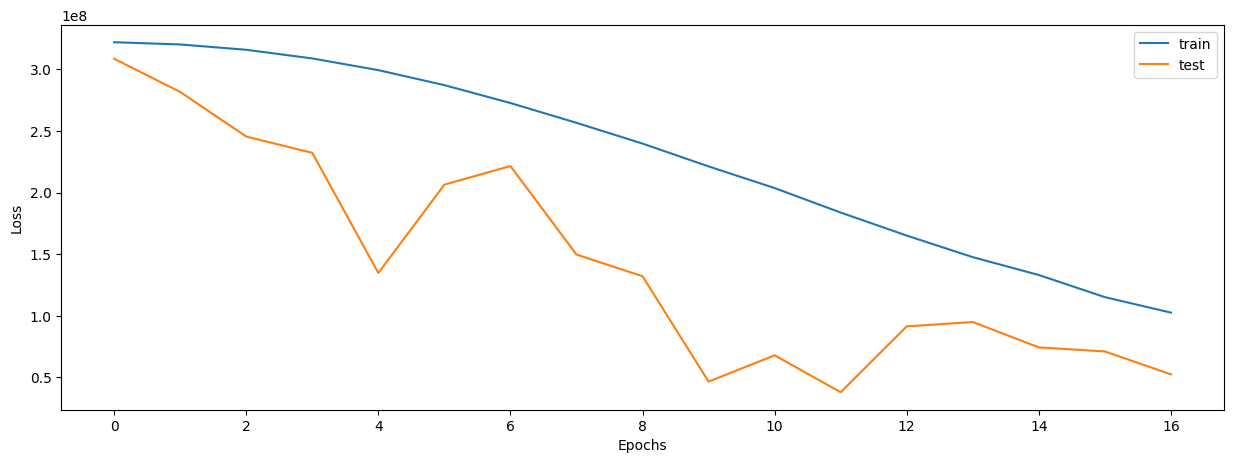

In [40]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

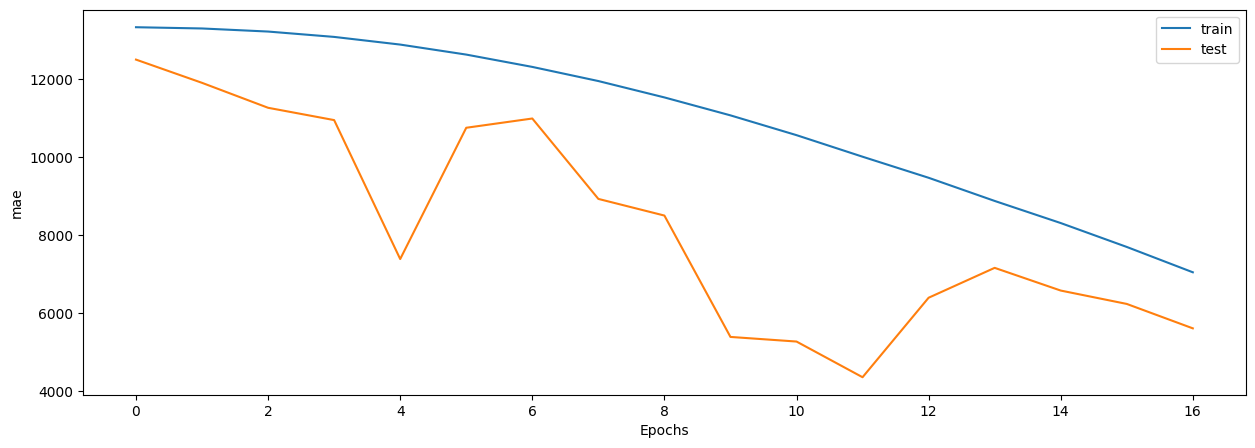

In [41]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

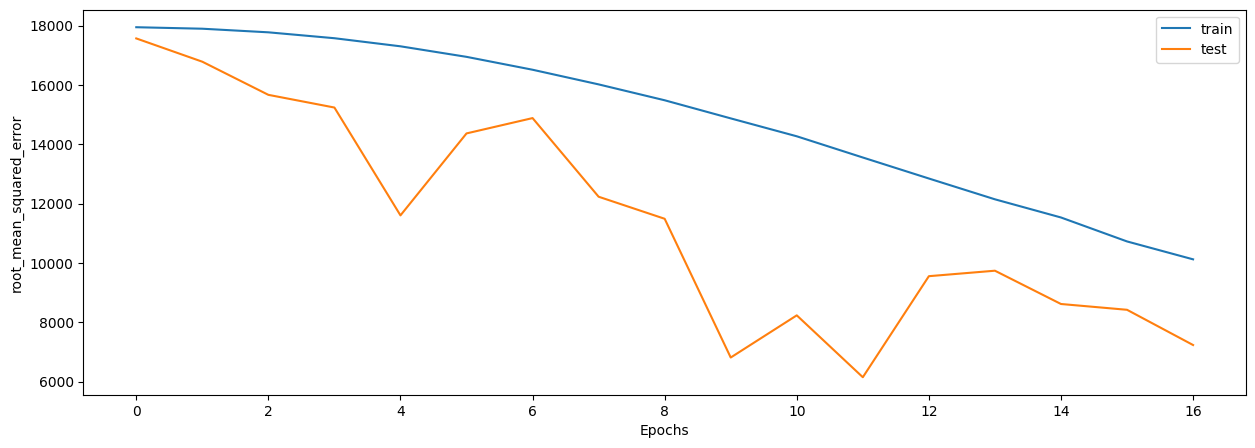

In [42]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['root_mean_squared_error'], label='train')
plt.plot(history.history['val_root_mean_squared_error'], label='test')
plt.xlabel('Epochs')
plt.ylabel('root_mean_squared_error')
plt.legend()
plt.show()